**IMPORTING LIBRARIES**

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**READING THE DATASET**

In [186]:
df = pd.read_csv("/dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


In [187]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


# **UNIVARIATE ANALYSIS**

In [188]:
df['Item'].dtype

dtype('O')

**or**

In [189]:
for col, dtype in df.dtypes.items():
    print(f"Column: {col}, Data type: {dtype}")

Column: Transaction ID, Data type: object
Column: Item, Data type: object
Column: Quantity, Data type: object
Column: Price Per Unit, Data type: object
Column: Total Spent, Data type: object
Column: Payment Method, Data type: object
Column: Location, Data type: object
Column: Transaction Date, Data type: object


**REMOVING INCONSISTENCY FROM DATATYPES**

In [190]:
repeating_value = df['Item'].mode()[0]
print(repeating_value)

df['Item'] = df['Item'].fillna(repeating_value)
print(df['Item'])

Juice
0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996       Juice
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: object


In [191]:
df['Quantity'].dropna()
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity']


,Quantity
0,2.0
1,4.0
2,4.0
3,2.0
4,2.0
...,...
9995,2.0
9996,3.0
9997,4.0
9998,3.0


**REPLACING NaN VALUES**

In [192]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())
df['Price Per Unit'] = df['Price Per Unit'].round(2)
df['Price Per Unit']


,Price Per Unit
0,2.00
1,3.00
2,1.00
3,5.00
4,2.00
...,...
9995,2.00
9996,2.95
9997,2.00
9998,2.95


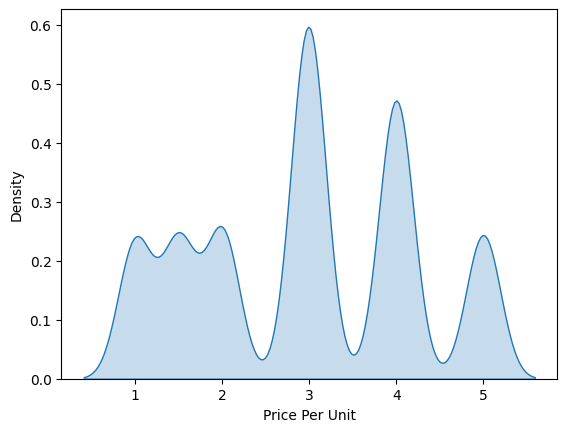

In [193]:
sns.kdeplot(df['Price Per Unit'], fill=True)
plt.show()

In [194]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].mean())
df['Total Spent'] = df['Total Spent'].round(2)
df['Total Spent']

,Total Spent
0,4.00
1,12.00
2,8.92
3,10.00
4,4.00
...,...
9995,4.00
9996,3.00
9997,8.00
9998,3.00


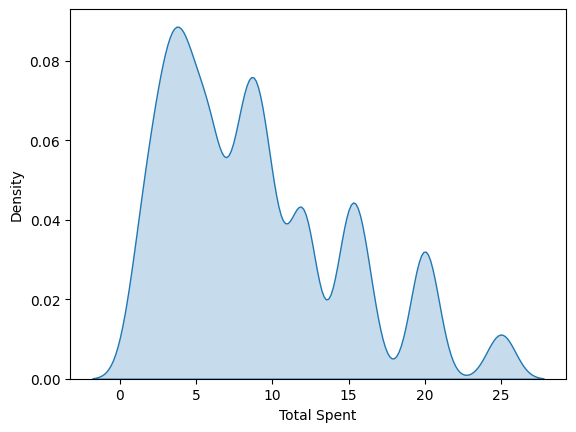

In [195]:
sns.kdeplot(df['Total Spent'], fill=True)
plt.show()

**BIVARIATE ANALYSIS**

In [196]:
crosstab = pd.crosstab(df['Price Per Unit'], df['Item'])
crosstab

Item,Cake,Coffee,Cookie,ERROR,Juice,Salad,Sandwich,Smoothie,Tea,UNKNOWN
Price Per Unit,,,,,,,,,,
1.00,0,0,1026,34,38,0,0,0,0,45
1.50,0,0,0,37,33,0,0,0,1023,40
2.00,0,1108,0,31,39,0,0,0,0,49
2.95,54,57,66,13,84,66,49,60,66,18
3.00,1085,0,0,77,1190,0,0,0,0,77
4.00,0,0,0,61,82,0,1082,1036,0,70
5.00,0,0,0,39,38,1082,0,0,0,45


In [197]:
crosstab2 = pd.crosstab(df['Quantity'], df['Item'])
crosstab2

Item,Cake,Coffee,Cookie,ERROR,Juice,Salad,Sandwich,Smoothie,Tea,UNKNOWN
Quantity,,,,,,,,,,
1.0,209,218,209,48,268,219,213,193,181,64
2.0,232,213,231,58,297,227,205,211,228,72
3.0,198,216,179,54,304,195,222,211,205,65
4.0,208,209,218,51,289,218,193,212,198,66
5.0,246,248,202,63,281,236,236,225,222,54
15.0,0,0,0,0,0,0,1,0,0,0


**MULTIVARIATE ANALYSIS**

In [198]:
numeric_data = df.select_dtypes(include="number")
corr_matrix = numeric_data.corr()
corr_matrix

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.006567,0.685016
Price Per Unit,0.006567,1.000000,0.612995
Total Spent,0.685016,0.612995,1.000000


<Axes: >

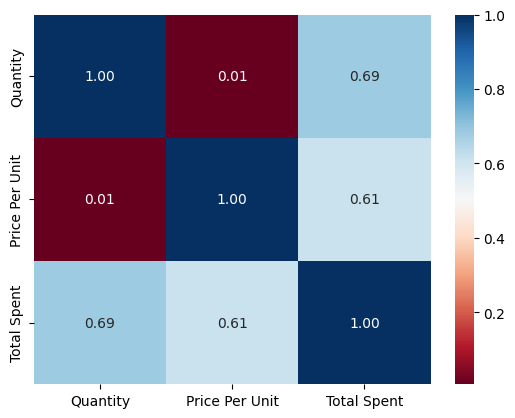

In [199]:
sns.heatmap(corr_matrix, annot=True, cmap = "RdBu", fmt = ".2f")

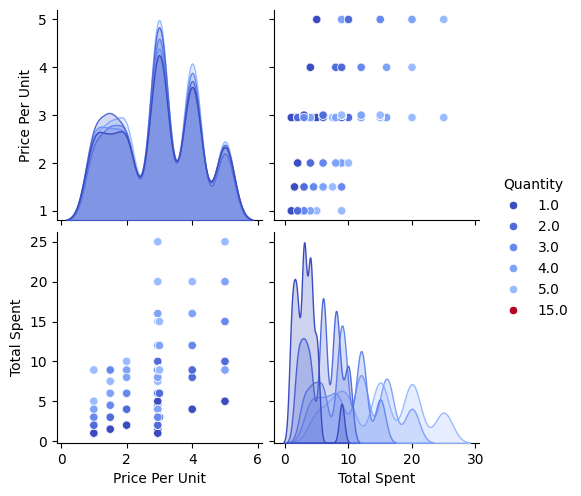

In [200]:
sns.pairplot(df[['Quantity', 'Price Per Unit', 'Total Spent']], hue = "Quantity", palette='coolwarm')

# **OUTLIER DETECTION**

**Z_Score Method**

In [201]:
quantity = df['Quantity']
z_scores = (quantity - quantity.mean())/quantity.std()

#identify outliers
Outliers1 = quantity[(z_scores > 3) | (z_scores < -3) ]
Outliers1

,Quantity
265,15.0


In [202]:
total_spent = df['Total Spent']
z_scores = (total_spent - total_spent.mean())/total_spent.std()

#identify outliers
Outliers2 = total_spent[(z_scores > 3) | (z_scores < -3) ]
Outliers2

,Total Spent


In [203]:
ppu = df['Price Per Unit']
z_scores = (ppu - ppu.mean())/ppu.std()

#identify outliers
Outliers3 = ppu[(z_scores > 3) | (z_scores < -3) ]
Outliers3

,Price Per Unit


**IQR Method**

In [238]:
 Q1 = df['Quantity'].quantile(0.25)
 Q3 = df['Quantity'].quantile(0.75)

 IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 + 1.5 * IQR
outliers_iqr = df[(df["Quantity"] < lower_bound) |
                  (df["Quantity"] > upper_bound)]["Quantity"]

print(outliers_iqr)

0       2.0
1       4.0
2       4.0
3       2.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    4.0
9998    3.0
9999    3.0
Name: Quantity, Length: 7508, dtype: float64


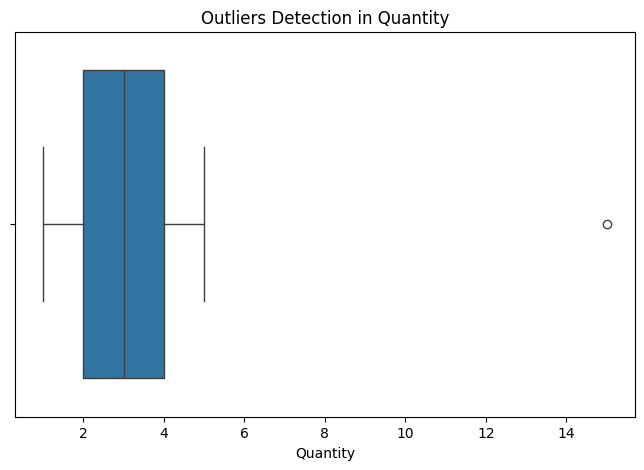

In [208]:
plt.figure(figsize = (8,5))
sns.boxplot(x = df['Quantity'])
plt.title("Outliers Detection in Quantity")
plt.show()

# **HANDLING OUTLIERS**

**Taking Log**

In [227]:
log_data = np.log(df['Quantity'] + 1).round(2)
log_data

,Quantity
0,1.10
1,1.61
2,1.61
3,1.10
4,1.10
...,...
9995,1.10
9996,1.39
9997,1.61
9998,1.39


**Square root**

In [234]:
sqr_root = np.sqrt(df['Quantity']).round(2)
sqr_root

,Quantity
0,1.41
1,2.00
2,2.00
3,1.41
4,1.41
...,...
9995,1.41
9996,1.73
9997,2.00
9998,1.73


**Box Cox**

In [248]:
data = df['Quantity']

# Remove or inspect NaNs/Infinite values

print("Any NaNs:", data.isna().any())
print("Any Infs:", np.isinf(data).any())

# Shift data to make all values positive
data_shifted = data - data.min() + 1

# Drop any remaining NaNs or non-finite values
data_shifted = data_shifted[np.isfinite(data_shifted)]

# Now apply Box-Cox
boxcox_data, lambda_value = stats.boxcox(data_shifted)
print("Optimal lambda:", lambda_value)

Any NaNs: True
Any Infs: False
Optimal lambda: 0.6828867406146306
